# Apendix 1 Average Feature Importance for Difference Treatment of Vy tested for $\Delta\!$ MLat
In this notebook we show how we perform the feature importance to test what time shift and averaging window has the highest feature importance for predicting $\Delta\!$ MLat


## Imports
First we import the functions we need

In [1]:
from multiprocessing import Pool # We use this to speed up the code by performing operations at the same time on different cpus
from sklearn.model_selection import train_test_split # This allows us to sample our dataset
from sklearn.ensemble import RandomForestRegressor # Key component for feature importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import iqr # interquartile range
from Boxplot import add_boxkey # Used to make a box plot key in figure
from progressbar import progressbar # progress tracker

## Settings
settings needed for all the plotting

In [2]:
colors= ['#003f5c', '#bc5090', '#ffa600']

medianprops={'color':colors[0], 'lw':2}
meanprops= {'color':colors[1], 'lw':2}
boxplot={'medianprops':medianprops, 'meanprops':meanprops}
barchart={'color':colors[2]}

# Loading Dataset
Loading Onset file and created $\Delta\!$ MLat column

In [3]:
Onsets= pd.read_csv('../Data/Mediated_Onsets.csv', parse_dates=['Date_NH'])
Onsets= Onsets[Onsets.flag==1][['Date_NH', 'Frey_MLT', 'Frey_MLAT', 'MLAT_SH']]
Onsets.loc[Onsets.Frey_MLT<12, 'Frey_MLT']+=24
Onsets['DMLAT']=Onsets['MLAT_SH']-Onsets['Frey_MLAT']

## Rounding Time
Rounding the NH image time to the nearest minute

In [4]:
diff= Onsets.Date_NH-Onsets.Date_NH.values.astype('datetime64[m]')
delta= np.zeros(diff.shape).astype('timedelta64[m]')
delta[diff.values>=np.timedelta64(30, 's')]=np.timedelta64(1, 'm')
Onsets['Date_UTC']=Onsets.Date_NH.values.astype('datetime64[m]').astype('datetime64[ns]')+delta

## Loading Omni
Load the omni data. Looping through each window and time shift.
Renaming columns and then merging all window means and time shifts into one file

In [5]:
keys=[]
shifts=[0, 10, 20]
windows=[30, 60, 120]

# Get keys needed
for window in progressbar(windows, prefix='Looping Windows | '):
    for t_shift in progressbar(shifts, prefix=f'Looping Shift, window: {window} | '):
        key=f'omni_window_{window}_shift_{t_shift}'
        keys.append(key)
# merge datasets and rename columns to show shift and window
for key in progressbar(keys, prefix='Looping keys for merging omni |'):
    omni= pd.read_hdf('../Data/omni_data.hdf5', key=key, columns=['Vy_Mean'])
    omni.rename(columns={'Vy_Mean':f'Vy_Window_{key.split("omni_window_")[-1]}'}, inplace=True)
    omni['Date_UTC']= omni.index.values
    omni.index= list(range(len(omni)))
    Onsets= Onsets.merge(omni, on='Date_UTC')
omni= pd.read_hdf('../Data/omni_data.hdf5', key=key, columns=['Vy'])
for shift in shifts:
    omni[f'Vy_Window_0_Shift_{shift}']= omni['Vy'].shift(shift)

omni['Date_UTC']= omni.index.values
omni.index= list(range(len(omni)))
Onsets= Onsets.merge(omni, on='Date_UTC')

Looping Windows |   0% (0 of 3) |        | Elapsed Time: 0:00:00 ETA:  --:--:--
Looping Shift, window: 30 |   0% (0 of 3) || Elapsed Time: 0:00:00 ETA:  --:--:--
Looping Shift, window: 30 | 100% (3 of 3) || Elapsed Time: 0:00:00 Time:  0:00:00
Looping Shift, window: 60 |   0% (0 of 3) || Elapsed Time: 0:00:00 ETA:  --:--:--
Looping Shift, window: 60 | 100% (3 of 3) || Elapsed Time: 0:00:00 Time:  0:00:00
Looping Shift, window: 120 |   0% (0 of 3) || Elapsed Time: 0:00:00 ETA:  --:--:--
Looping Shift, window: 120 | 100% (3 of 3) || Elapsed Time: 0:00:00 Time:  0:00:00
Looping Windows | 100% (3 of 3) |########| Elapsed Time: 0:00:00 Time:  0:00:00
Looping keys for merging omni |  0% (0 of 9) || Elapsed Time: 0:00:00 ETA:  --:--:--
Looping keys for merging omni | 11% (1 of 9) || Elapsed Time: 0:00:04 ETA:   0:00:35
Looping keys for merging omni | 22% (2 of 9) || Elapsed Time: 0:00:08 ETA:   0:00:25
Looping keys for merging omni | 33% (3 of 9) || Elapsed Time: 0:00:12 ETA:   0:00:23
Loopin

## Selecting Feature Columns

In [6]:
columns= [f'Vy_Window_0_Shift_{shift}' for shift in shifts]+[f'Vy_Window_{key.split("omni_window_")[-1]}' for key in keys]
for col in ['DMLAT']+columns:
    Onsets[col]= np.round(Onsets[col], 15)

## Creating Random Feature
We fix the seed so the results are reproducable

In [7]:
np.random.seed(42)
Onsets['Random']= np.random.uniform(0, 1, size=len(Onsets))


## Handling Outliers
We use 1.5 times the interquartile range over and under the upper and lower quartiles to define outliers and exclude them from feature importance

In [8]:
upper_lim= Onsets.DMLAT<np.quantile(Onsets.DMLAT, .75)+iqr(Onsets.DMLAT)*1.5
lower_lim= Onsets.DMLAT>np.quantile(Onsets.DMLAT, .25)-iqr(Onsets.DMLAT)*1.5
rm_out= upper_lim&lower_lim
ind= np.ones(len(Onsets)).astype(bool)
for key in progressbar(keys, prefix='Looping keys for nan check |'):
    ind&= Onsets[f'Vy_Window_{key.split("omni_window_")[-1]}'].notnull()
Onsets= Onsets[rm_out&Onsets.Vy.notnull()&ind] # we also remove rows with no bowshock omni and averaged omni that does not have enough data points in the window


Looping keys for nan check |  0% (0 of 9) || Elapsed Time: 0:00:00 ETA:  --:--:--
Looping keys for nan check |100% (9 of 9) || Elapsed Time: 0:00:00 Time:  0:00:00


## Feature Importance Definition
We create the feature importance function and set the seeds for seed cycling and repeated cross validation.
We also define X and y where X is are features we want to find the importance for and y is the feature to predict ($\Delta\!$ MLat)

In [9]:
X= Onsets[['Random']+columns]
y = Onsets.DMLAT

# Define the number of splits and list of seeds
n_splits = 20
seed_list = [42, 123, 456, 789, 101112]  # list of seeds

def train_and_get_feature_importance(seed):
    # Initialize feature importance list for this seed
    seed_feature_importance = []
    
    # Repeat train-test split and model training for each split
    for split_seed in [246, 357, 468, 579, 680, 791, 802, 913, 1024, 1135, 1246, 
              1357, 1468, 1579, 1680, 1791, 1802, 1913, 2024, 2135]:
        # Perform train-test split with current seed
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=split_seed) # This is used to create a sample of 80% of the data points to use in the feature importance
        
        # Initialize and train Random Forest Regressorrm_out&Onsets.BY_GSM_Mean.notnull()&Onsets.BY_GSM.no
        rf_regressor = RandomForestRegressor(random_state=seed)
        rf_regressor.fit(X_train, y_train)
        
        # Get feature importance and append to list
        seed_feature_importance.append(rf_regressor.feature_importances_)
    
    # Return mean feature importance for this seed
    return np.array(seed_feature_importance)


## Run Feature Importance
We use pool to speed up the feature importance so that more than one feature importance is being calculated at the same time and we output it into one array. This creates our distribution of feature importance

In [10]:
# Create a Pool of workers
with Pool() as pool:
    # Map the train_and_get_feature_importance function to the seed_list
    feature_importance = pool.map(train_and_get_feature_importance, seed_list)
feature_importance= np.concatenate(feature_importance)
# Calculate mean feature importance across all seeds
FI= mean_feature_importance = np.mean(feature_importance, axis=0)


## Plotting Results
We use a bar chart for the average feature importance and box plots for each distribution

Text(0.5, 0.98, '$\\Delta$MLat Average Random Forest\nFeature Importance')

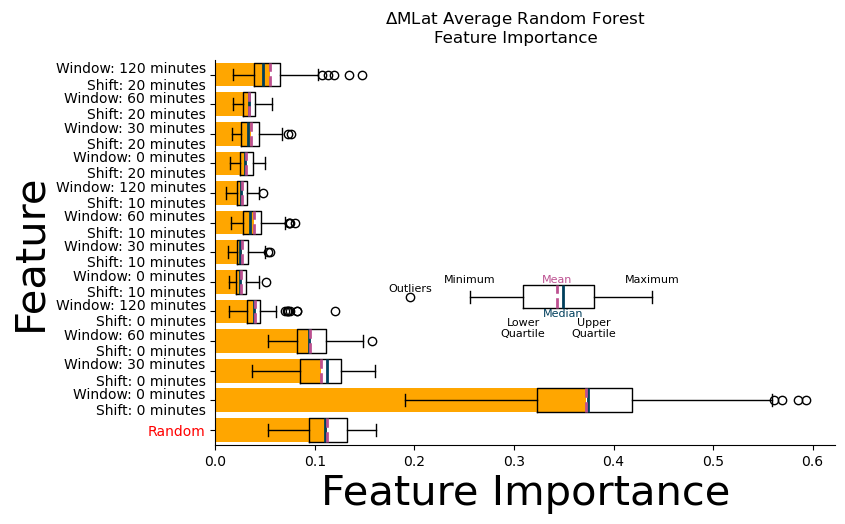

In [11]:
# mean_feature_importance contains the stable estimate of feature importance
fig= plt.figure(figsize=(8, 5))
ax=fig.add_subplot()

# Bar chart for the mean feature importance
bar= ax.barh(X.columns, FI, **barchart)
add_boxkey(ax, width=[round(Bar.get_bbox().height, 1) for Bar in bar.get_children()][0],
           ypos=4.5, boxplotkwargs=boxplot)

# Box plots for the feature importance distributions
ax.boxplot(feature_importance, vert=False, positions=range(0, len(X.columns)),
           widths= [round(Bar.get_bbox().height, 1) for Bar in bar.get_children()],
           showmeans = True, meanline = True, **boxplot)
# Defining Column Strings
if not 'Random' in columns:
    columns= ['Random']+columns

columns= ['Random']+[f'Window: {window} minutes\nShift: {shift} minutes' for shift in shifts for window in [0]+windows]

ax.set_yticks(list(range(0, len(columns))))

ax.set_yticklabels(columns)
ax.get_yticklabels()[0].set_color('r')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Feature', size=30)
ax.set_xlabel('Feature Importance', size=30)
fig.suptitle('$\Delta$MLat Average Random Forest\nFeature Importance')